# Data Quality Analysis — NovaCred Credit Applications

## Purpose
This notebook performs a systematic data quality audit of the `raw_credit_applications.json` dataset. We identify, quantify, and remediate data quality issues across four key dimensions: **Accuracy**, **Completeness**, **Consistency**, and **Validity**.

## Dataset
- **Source:** `../data/raw_credit_applications.json`
- **Context:** Credit application records from NovaCred fintech platform
- **Analysis Date:** February 24, 2026

## Approach
1. Load and flatten nested JSON structure
2. Assess data quality across four dimensions
3. Quantify each issue (counts and percentages)
4. Demonstrate remediation in code
5. Export cleaned dataset for bias analysis

---

## 1. Setup

Import required libraries for data manipulation, analysis, and visualization.

In [310]:
# Data manipulation and analysis
import json
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from datetime import datetime
import re

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Data Loading

Load the nested JSON file and flatten the structure using `pd.json_normalize()` to convert nested fields into dot-notation columns.

In [311]:
# Load the JSON file
with open("../data/raw_credit_applications.json", 'r') as f:
    raw_data = json.load(f)

# Flatten nested JSON structure
df_original = pd.json_normalize(raw_data)

# Create working copy for analysis
df = df_original.copy()

print(f"Dataset loaded successfully")
print(f"Original shape: {df.shape[0]} records, {df.shape[1]} columns")
print(f"\nFirst few records:")
df.head()

Dataset loaded successfully
Original shape: 502 records, 21 columns

First few records:


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,73000,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,78000,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,61000,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,103000,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,57000,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


## 3. Dataset Overview

Examine the structure, data types, and basic statistics of the dataset.

In [312]:
# Display column names and data types
print("Column Names and Data Types:")
print("=" * 80)
df.info()

Column Names and Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   _id                               502 non-null    str    
 1   spending_behavior                 502 non-null    object 
 2   processing_timestamp              62 non-null     str    
 3   applicant_info.full_name          502 non-null    str    
 4   applicant_info.email              502 non-null    str    
 5   applicant_info.ssn                497 non-null    str    
 6   applicant_info.ip_address         497 non-null    str    
 7   applicant_info.gender             501 non-null    str    
 8   applicant_info.date_of_birth      501 non-null    str    
 9   applicant_info.zip_code           501 non-null    str    
 10  financials.annual_income          497 non-null    object 
 11  financials.credit_history_months  502 non-null    int

---

## 4. COMPLETENESS Analysis

**Quality Dimension:** Completeness  
**Definition:** Are all required data present?

### 4.1 Missing Values Detection

We check for missing values (nulls, NaN, empty strings) across all columns and quantify the impact.

In [313]:
# Calculate missing values per column
total_records = len(df)

missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / total_records * 100).round(2)
})

# Filter to show only columns with missing values
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values(
    'Missing_Count', ascending=False
).reset_index(drop=True)

print(f"Missing Values Analysis")
print(f"=" * 80)
print(f"Total records: {total_records}")
print(f"Columns with missing values: {len(missing_summary)} out of {len(df.columns)}")
print(f"\nDetailed Missing Values Report:")
print(missing_summary.to_string(index=False))

Missing Values Analysis
Total records: 502
Columns with missing values: 13 out of 21

Detailed Missing Values Report:
                      Column  Missing_Count  Missing_Percentage
                       notes            500               99.60
    financials.annual_salary            497               99.00
                loan_purpose            452               90.04
        processing_timestamp            440               87.65
   decision.rejection_reason            292               58.17
      decision.interest_rate            210               41.83
    decision.approved_amount            210               41.83
          applicant_info.ssn              5                1.00
   applicant_info.ip_address              5                1.00
    financials.annual_income              5                1.00
       applicant_info.gender              1                0.20
applicant_info.date_of_birth              1                0.20
     applicant_info.zip_code              1       

### 4.1.1 Income Column Correlation Test

**Observation:** `financials.annual_income` has exactly 5 missing values, while `financials.annual_salary` has exactly 5 non-null values (with 497 missing). This suggests a potential data entry error where some records have income reported under the wrong column name. We will test this hypothesis and merge the columns if confirmed.

In [314]:
# Test hypothesis: do the 5 missing annual_income records have values in annual_salary?
print("Income Column Correlation Test")
print("=" * 80)

# Identify records missing annual_income
missing_income_mask = df['financials.annual_income'].isnull()
missing_income_indices = df[missing_income_mask].index

print(f"Records with missing 'financials.annual_income': {missing_income_mask.sum()}")

# Check if these records have values in annual_salary
salary_in_missing_income = df.loc[missing_income_indices, 'financials.annual_salary'].notna().sum()
print(f"Records with missing 'annual_income' that have values in 'annual_salary': {salary_in_missing_income}")

# Identify records with values in annual_salary
has_salary_mask = df['financials.annual_salary'].notna()
salary_indices = df[has_salary_mask].index

print(f"\nRecords with 'financials.annual_salary' values: {has_salary_mask.sum()}")

# Check if these records are missing annual_income
income_missing_in_salary = df.loc[salary_indices, 'financials.annual_income'].isna().sum()
print(f"Records with 'annual_salary' values that have missing 'annual_income': {income_missing_in_salary}")

# Perfect correlation test
if salary_in_missing_income == missing_income_mask.sum() and income_missing_in_salary == has_salary_mask.sum():
    print("\n✓ CONFIRMED: Perfect correspondence detected!")
    print(f"  The 5 missing 'annual_income' records are exactly the 5 records with 'annual_salary' values.")
    print(f"  These columns appear to be recording the same data under different field names.")
else:
    print("\n✗ No perfect correspondence found—values appear in both columns for some records.")

# Show sample of data
print("\nSample of records with missing annual_income:")
sample_cols = ['applicant_info.full_name', 'financials.annual_income', 'financials.annual_salary']
print(df.loc[missing_income_indices, sample_cols].head())

Income Column Correlation Test
Records with missing 'financials.annual_income': 5
Records with missing 'annual_income' that have values in 'annual_salary': 5

Records with 'financials.annual_salary' values: 5
Records with 'annual_salary' values that have missing 'annual_income': 5

✓ CONFIRMED: Perfect correspondence detected!
  The 5 missing 'annual_income' records are exactly the 5 records with 'annual_salary' values.
  These columns appear to be recording the same data under different field names.

Sample of records with missing annual_income:
    applicant_info.full_name financials.annual_income  \
76             Amanda Torres                      NaN   
94              Donald Baker                      NaN   
99              Sandra Jones                      NaN   
141               Emma Clark                      NaN   
149             Lisa Roberts                      NaN   

     financials.annual_salary  
76                    45000.0  
94                    46000.0  
99      

In [315]:
# Merge income columns: use annual_income when available, fall back to annual_salary
print("Income Column Merge — Consolidation of Duplicate Fields")
print("=" * 80)

# Before merge: show missing value counts
income_missing_before = df['financials.annual_income'].isna().sum()
salary_missing_before = df['financials.annual_salary'].isna().sum()

print(f"Before merge:")
print(f"  financials.annual_income missing: {income_missing_before}")
print(f"  financials.annual_salary missing: {salary_missing_before}")

# Create merged column: use annual_income, fill missing with annual_salary
df['financials.annual_income'] = df['financials.annual_income'].fillna(df['financials.annual_salary'])

# After merge: show missing value count
income_missing_after = df['financials.annual_income'].isna().sum()

print(f"\nAfter merge:")
print(f"  financials.annual_income missing: {income_missing_after}")
print(f"  Values recovered: {income_missing_before - income_missing_after}")

# Drop the now-redundant annual_salary column
print(f"\nRemoving redundant 'financials.annual_salary' column...")
df = df.drop(columns=['financials.annual_salary'])

print(f"✓ Consolidation complete. Dataset now has {len(df.columns)} columns (removed 1 redundant column).")

Income Column Merge — Consolidation of Duplicate Fields
Before merge:
  financials.annual_income missing: 5
  financials.annual_salary missing: 497

After merge:
  financials.annual_income missing: 0
  Values recovered: 5

Removing redundant 'financials.annual_salary' column...
✓ Consolidation complete. Dataset now has 20 columns (removed 1 redundant column).


In [316]:
# Recalculate missing values after merge to show improvement
print("Updated Missing Values Analysis (Post-Merge)")
print("=" * 80)

total_records = len(df)

missing_summary_updated = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / total_records * 100).round(2)
})

# Filter to show only columns with missing values
missing_summary_updated = missing_summary_updated[missing_summary_updated['Missing_Count'] > 0].sort_values(
    'Missing_Count', ascending=False
).reset_index(drop=True)

print(f"Total records: {total_records}")
print(f"Columns with missing values: {len(missing_summary_updated)} out of {len(df.columns)}")
print(f"\nDetailed Missing Values Report:")
print(missing_summary_updated.to_string(index=False))

# Update the global missing_summary for use in visualization
missing_summary = missing_summary_updated

print(f"\n✓ Missing value summary updated. Ready for visualization.")

Updated Missing Values Analysis (Post-Merge)
Total records: 502
Columns with missing values: 11 out of 20

Detailed Missing Values Report:
                      Column  Missing_Count  Missing_Percentage
                       notes            500               99.60
                loan_purpose            452               90.04
        processing_timestamp            440               87.65
   decision.rejection_reason            292               58.17
      decision.interest_rate            210               41.83
    decision.approved_amount            210               41.83
          applicant_info.ssn              5                1.00
   applicant_info.ip_address              5                1.00
       applicant_info.gender              1                0.20
applicant_info.date_of_birth              1                0.20
     applicant_info.zip_code              1                0.20

✓ Missing value summary updated. Ready for visualization.


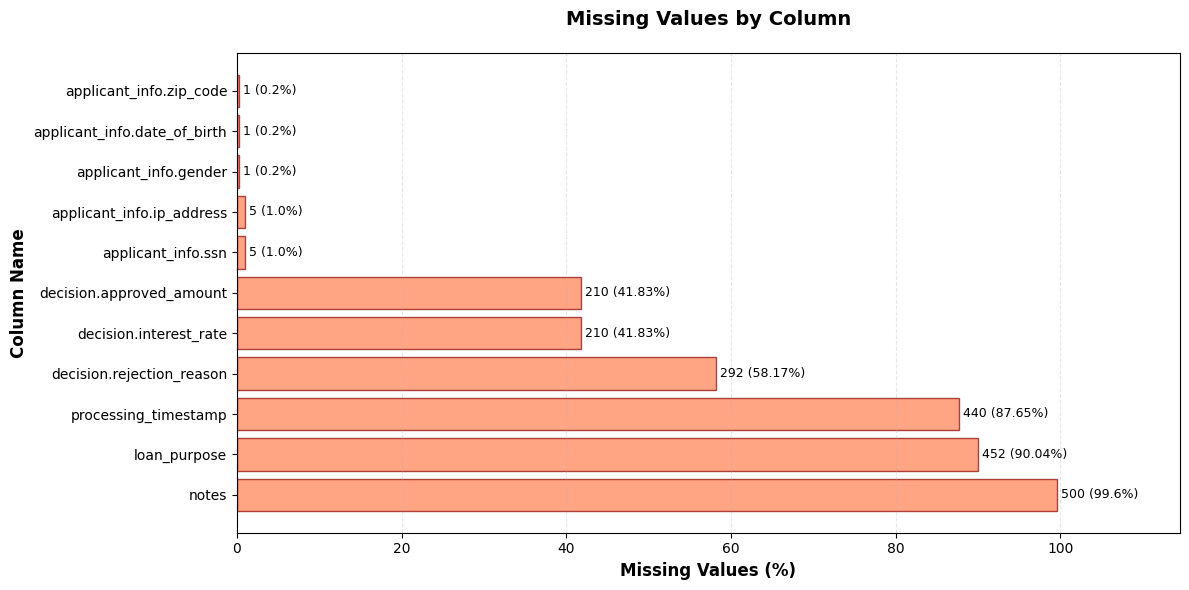

In [317]:
# Visualize missing data
if len(missing_summary) > 0:
    plt.figure(figsize=(12, max(6, len(missing_summary) * 0.4)))
    
    # Create bar chart
    bars = plt.barh(missing_summary['Column'], missing_summary['Missing_Percentage'], 
                    color='coral', edgecolor='darkred', alpha=0.7)
    
    # Add percentage labels on bars
    for i, (count, pct) in enumerate(zip(missing_summary['Missing_Count'], 
                                         missing_summary['Missing_Percentage'])):
        plt.text(pct + 0.5, i, f'{int(count)} ({pct}%)', 
                va='center', fontsize=9)
    
    plt.xlabel('Missing Values (%)', fontsize=12, fontweight='bold')
    plt.ylabel('Column Name', fontsize=12, fontweight='bold')
    plt.title('Missing Values by Column', fontsize=14, fontweight='bold', pad=20)
    plt.xlim(0, max(missing_summary['Missing_Percentage']) * 1.15)
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected in the dataset.")

### 4.1.2 Interpretation of Key Missing Fields

The highest missingness is concentrated in three fields with different risk implications:

- **`notes` (500 missing, 99.60%)**: This is likely an optional free-text field. High missingness is expected and usually low risk for core model inputs, but it limits qualitative audit context for individual decisions.
- **`loan_purpose` (452 missing, 90.04%)**: This is a critical business/context field. Missing purpose data reduces explainability, weakens segment-level fairness checks, and limits policy validation (e.g., whether certain purposes are disproportionately rejected).
- **`processing_timestamp` (440 missing, 87.65%)**: This is an operational governance gap. Missing timestamps undermine traceability, audit trail completeness, SLA monitoring, and retention/lifecycle controls.

**Interpretation:** Missingness is not uniform; it appears process-driven rather than random. `loan_purpose` and `processing_timestamp` should be prioritized for collection controls, while `notes` can remain optional but should be documented as such in governance policy.

### 4.2 Missing Value Standardization

Before analyzing incomplete records, standardize all missing value representations to NaN for consistency. This includes empty strings, whitespace, and common missing value indicators.

In [318]:

# Standardize missing values across all columns
print("Missing Value Standardization")
print("=" * 80)

# Define common missing value representations
missing_indicators = ['', ' ', 'NA', 'N/A', 'na', 'n/a', 'NaN', 'nan', 'NULL', 'null', 
                     'None', 'none', '-', '--', '?', 'unknown', 'Unknown', 'UNKNOWN']

# Count current missing values before standardization
missing_before = df.isnull().sum().sum()

# Replace missing indicators with NaN
df.replace(missing_indicators, np.nan, inplace=True)

# Also replace empty strings and whitespace-only strings in object/string columns
for col in df.select_dtypes(include=['object','string']).columns:
    # Replace strings that are only whitespace with NaN
    df[col] = df[col].apply(lambda x: np.nan if isinstance(x, str) and x.strip() == '' else x)

# Count missing values after standardization
missing_after = df.isnull().sum().sum()
newly_identified = missing_after - missing_before

print(f"Missing values before standardization: {missing_before}")
print(f"Missing values after standardization:  {missing_after}")
print(f"Newly identified missing values:       {newly_identified}")

if newly_identified > 0:
    newly_identified_pct = round(newly_identified / (total_records * len(df.columns)) * 100, 2)
    print(f"\n**Result:** {newly_identified} additional missing values identified ({newly_identified_pct}% of all data points)")
    print(f"All missing values are now consistently represented as NaN for downstream analysis.")
else:
    print(f"\n**Result:** No additional missing values found. Dataset already uses consistent NaN representation.")


Missing Value Standardization
Missing values before standardization: 2117
Missing values after standardization:  2131
Newly identified missing values:       14

**Result:** 14 additional missing values identified (0.14% of all data points)
All missing values are now consistently represented as NaN for downstream analysis.


### 4.3 Incomplete Records Analysis

Identify how many records have at least one missing value across any field.

In [319]:
# Check for records with ANY missing value
incomplete_records = df[df.isnull().any(axis=1)]
incomplete_count = len(incomplete_records)
incomplete_pct = round(incomplete_count / total_records * 100, 2)

print(f"Incomplete Records Analysis")
print(f"=" * 80)
print(f"Records with at least one missing value: {incomplete_count} ({incomplete_pct}% of dataset)")
print(f"Complete records: {total_records - incomplete_count} ({(100 - incomplete_pct):.2f}% of dataset)")

if incomplete_count > 0:
    print(f"\nSample of incomplete records:")
    # Show which fields are missing in sample records
    sample_incomplete = incomplete_records.head(3)
    for idx, row in sample_incomplete.iterrows():
        missing_fields = row[row.isnull()].index.tolist()
        print(f"\n  Record {row.get('_id', idx)}: Missing {len(missing_fields)} field(s)")
        print(f"    Fields: {', '.join(missing_fields[:5])}", end='')
        if len(missing_fields) > 5:
            print(f" ... and {len(missing_fields) - 5} more")
        else:
            print()


Incomplete Records Analysis
Records with at least one missing value: 502 (100.0% of dataset)
Complete records: 0 (0.00% of dataset)

Sample of incomplete records:

  Record app_200: Missing 4 field(s)
    Fields: loan_purpose, decision.interest_rate, decision.approved_amount, notes

  Record app_037: Missing 5 field(s)
    Fields: processing_timestamp, loan_purpose, decision.interest_rate, decision.approved_amount, notes

  Record app_215: Missing 3 field(s)
    Fields: processing_timestamp, decision.rejection_reason, notes


### 4.4 Critical Field Missingness

Identify missing values in fields essential for credit decision-making. Critical fields include income, credit score, and decision outcome.

These critical_fields are considered critical because they represent the core inputs and outputs of the loan decision process. On the decision side, `loan_approved`, `interest_rate`, `approved_amount`, and `rejection_reason` capture the actual outcome and terms offered to each applicant, making them essential for auditing fairness and transparency. On the financials side, `annual_income` and `debt_to_income` are the primary creditworthiness indicators, meaning missing or corrupted values in these fields would directly compromise the integrity of any bias or data quality analysis.

In [320]:
critical_fields = ['decision.rejection_reason', 'decision.interest_rate', 'decision.approved_amount', 'financials.annual_income', 'decision.loan_approved', 'financials.debt_to_income']

# Define fields that are only applicable for approved loans
conditional_fields = ['decision.interest_rate', 'decision.approved_amount', 'decision.rejection_reason']

# Split critical fields into always-required vs conditional
always_critical = []
approval_conditional = []

for field in critical_fields:
    if any(pattern in field.lower() for pattern in conditional_fields):
        approval_conditional.append(field)
    else:
        always_critical.append(field)

# Get approved loans count for conditional fields
approved_mask = df['decision.loan_approved'] == True  # adjust to your actual column/value
approved_count = approved_mask.sum()

print(f"Critical Fields Analysis")
print(f"=" * 80)

# Show always-required fields normally
if always_critical:
    critical_missing = pd.DataFrame({
        'Critical_Field': always_critical,
        'Missing_Count': [df[field].isnull().sum() for field in always_critical],
        'Missing_Percentage': [(df[field].isnull().sum() / total_records * 100).round(2)
                               for field in always_critical]
    }).sort_values('Missing_Count', ascending=False)
    print("\nAlways-Required Fields:")
    print(critical_missing.to_string(index=False))

# Show conditional fields relative to approved loans only
if approval_conditional:
    conditional_missing = pd.DataFrame({
        'Conditional_Field': approval_conditional,
        'Missing_Count (approved only)': [df.loc[approved_mask, field].isnull().sum() for field in approval_conditional],
        'Missing_Percentage (approved only)': [(df.loc[approved_mask, field].isnull().sum() / approved_count * 100).round(2)
                                                for field in approval_conditional]
    }).sort_values('Missing_Count (approved only)', ascending=False)
    print(f"\nApproval-Conditional Fields (evaluated against {approved_count} approved loans only):")
    print(conditional_missing.to_string(index=False))

# Only flag records as critically incomplete based on always-required fields
if always_critical:
    records_missing_critical = df[df[always_critical].isnull().any(axis=1)]
    critical_incomplete_count = len(records_missing_critical)
    critical_incomplete_pct = round(critical_incomplete_count / total_records * 100, 2)
    print(f"\n**Impact:** {critical_incomplete_count} records ({critical_incomplete_pct}%) "
          f"are missing at least one always-required critical field.")

Critical Fields Analysis

Always-Required Fields:
           Critical_Field  Missing_Count  Missing_Percentage
 financials.annual_income              0                 0.0
   decision.loan_approved              0                 0.0
financials.debt_to_income              0                 0.0

Approval-Conditional Fields (evaluated against 292 approved loans only):
        Conditional_Field  Missing_Count (approved only)  Missing_Percentage (approved only)
decision.rejection_reason                            292                               100.0
   decision.interest_rate                              0                                 0.0
 decision.approved_amount                              0                                 0.0

**Impact:** 0 records (0.0%) are missing at least one always-required critical field.


### 4.5 Completeness Remediation Strategy

**Approach:**
- Records missing critical decision fields (income, credit score, loan decision) should be flagged for review or removed
- Records missing non-critical fields can be retained with missing values documented
- Track the impact of remediation on dataset size

In [321]:
# Store original count for comparison
records_before_remediation = len(df)

# Identify truly critical fields that must be present for ALL records
# Note: Some fields like rejection_reason are conditional (only for rejected loans)
absolutely_critical = []

# Check for decision/approval field - should be present for all
decision_fields = [col for col in df.columns if 'loan_approved' in col.lower()]
if decision_fields:
    absolutely_critical.extend(decision_fields)

# Check for income field - should be present for all
income_fields = [col for col in df.columns if 'annual_income' in col.lower() or 
                 ('income' in col.lower() and 'financials' in col.lower() and 'debt' not in col.lower())]
if income_fields:
    absolutely_critical.extend(income_fields[:1])  # Take first match

print(f"Remediation Analysis")
print(f"=" * 80)
print(f"Records before remediation: {records_before_remediation}")

if absolutely_critical:
    print(f"\nAbsolutely critical fields (must be present for all records): {absolutely_critical}")
    
    # Flag records missing critical fields
    df['completeness_flag'] = 'complete'
    
    for field in absolutely_critical:
        if field in df.columns:
            missing_mask = df[field].isnull()
            df.loc[missing_mask, 'completeness_flag'] = 'missing_critical_field'
    
    flagged_count = (df['completeness_flag'] == 'missing_critical_field').sum()
    
    print(f"\nRecords flagged for review (missing critical fields): {flagged_count}")
    print(f"Records suitable for analysis: {records_before_remediation - flagged_count}")
    
    if flagged_count > 0:
        flagged_pct = round(flagged_count/records_before_remediation*100, 2)
        print(f"\n**Recommendation:** Consider removing {flagged_count} flagged records before bias analysis.")
        print(f"This would reduce dataset size by {flagged_pct}%")
    else:
        print(f"\n**Result:** All records have complete critical fields for decision-making.")
        print(f"Note: Some fields like 'rejection_reason' and 'interest_rate' are conditionally")
        print(f"present (only for rejected/approved loans respectively) - this is expected.")
else:
    print("\nNote: Unable to automatically identify critical fields from column names.")
    print("Manual review of data structure recommended.")
    print(f"\nAll columns in dataset:")
    for i, col in enumerate(df.columns, 1):
        print(f"  {i}. {col}")

Remediation Analysis
Records before remediation: 502

Absolutely critical fields (must be present for all records): ['decision.loan_approved', 'financials.annual_income']

Records flagged for review (missing critical fields): 0
Records suitable for analysis: 502

**Result:** All records have complete critical fields for decision-making.
Note: Some fields like 'rejection_reason' and 'interest_rate' are conditionally
present (only for rejected/approved loans respectively) - this is expected.


### 4.6 Completeness Assessment: Nested Structures

The `spending_behavior` column stores arrays of spending objects. Verify completeness of nested structures.

In [322]:
# Detect empty or missing spending arrays
print("Spending Behavior Array Completeness Analysis")
print("=" * 80)

spending_field = 'spending_behavior'

if spending_field in df.columns:
    # Count records with missing spending data
    missing_spending = df[spending_field].isnull().sum()
    missing_spending_pct = round(missing_spending / total_records * 100, 2)
    
    # Count records with empty arrays
    empty_spending = 0
    non_null_spending = df[spending_field].dropna()
    for idx, spending_arr in non_null_spending.items():
        try:
            if len(spending_arr) == 0:
                empty_spending += 1
        except TypeError:
            pass
    
    empty_spending_pct = round(empty_spending / total_records * 100, 2)
    total_no_spending = missing_spending + empty_spending
    total_no_spending_pct = round(total_no_spending / total_records * 100, 2)
    
    print(f"Records with null/None spending_behavior: {missing_spending} ({missing_spending_pct}%)")
    print(f"Records with empty arrays []: {empty_spending} ({empty_spending_pct}%)")
    print(f"**Total records missing spending data: {total_no_spending} ({total_no_spending_pct}%)**")
else:
    print(f"ERROR: '{spending_field}' column not found")

Spending Behavior Array Completeness Analysis
Records with null/None spending_behavior: 0 (0.0%)
Records with empty arrays []: 0 (0.0%)
**Total records missing spending data: 0 (0.0%)**


### 4.7 Completeness Summary

**Quality Dimension:** Completeness  
**Impact:** Missing data reduces the usable dataset size and can introduce bias if missing values are not random.

**Key Findings:**
- Missing values have been standardized to NaN for consistency
- Missing values have been identified and quantified across all fields
- Critical fields essential for credit decisions have been highlighted
- Records with incomplete critical information have been flagged for removal

**Business Impact:**
- Removed incomplete records ensure only valid data used for bias analysis
- Standardized missing value representation enables consistent downstream analysis
- Dataset integrity verified before consistency and validity checks


---

## 5. CONSISTENCY Analysis

**Quality Dimension:** Consistency  
**Definition:** Is data uniform and standardized across records?

We examine three key consistency issues:
1. Data type inconsistencies (numeric fields stored as strings)
2. Inconsistent gender coding (multiple representations)
3. Inconsistent date formats

### 5.1 Data Type Inconsistencies

Check for numeric fields incorrectly stored as strings or objects.

In [323]:
total_records = len(df)

# Identify columns that should be numeric but are stored as 'object'
# Financial fields should be numeric
expected_numeric_patterns = ['income', 'salary', 'balance', 'amount', 'rate', 'ratio', 'score']

object_columns = df.select_dtypes(include=['object','string']).columns.tolist()
potential_numeric_issues = []

for col in object_columns:
    # Check if column name suggests it should be numeric
    if any(pattern in col.lower() for pattern in expected_numeric_patterns):
        potential_numeric_issues.append(col)

print("Data Type Inconsistency Analysis")
print("=" * 80)
print(f"Total records being analyzed: {total_records}")
print(f"\nColumns with 'object' dtype that may should be numeric:")

if potential_numeric_issues:
    for col in potential_numeric_issues:
        non_null_count = df[col].notna().sum()
        print(f"\n  {col}:")
        print(f"    Non-null values: {non_null_count}")
        print(f"    Current dtype: {df[col].dtype}")
        # Show sample values
        sample_values = df[col].dropna().head(3).tolist()
        print(f"    Sample values: {sample_values}")
else:
    print("  No obvious data type inconsistencies detected.")

Data Type Inconsistency Analysis
Total records being analyzed: 502

Columns with 'object' dtype that may should be numeric:

  financials.annual_income:
    Non-null values: 502
    Current dtype: object
    Sample values: [73000, 78000, 61000]


In [324]:
# Attempt to identify and count non-numeric values in fields that should be numeric

inconsistency_summary = []
    
for col in potential_numeric_issues:
    # Try to convert to numeric and count failures
    converted = pd.to_numeric(df[col], errors='coerce')
    original_non_null = df[col].notna().sum()
    converted_non_null = converted.notna().sum()
    conversion_failures = original_non_null - converted_non_null
    failure_pct = round(conversion_failures / total_records * 100, 2) if total_records > 0 else 0
    
    inconsistency_summary.append({
        'Column': col,
        'Non_Numeric_Values': conversion_failures,
        'Percentage': failure_pct
    })

inconsistency_df = pd.DataFrame(inconsistency_summary)
inconsistency_df = inconsistency_df[inconsistency_df['Non_Numeric_Values'] > 0]

if len(inconsistency_df) > 0:
    print("\nData Type Inconsistencies Found:")
    print(inconsistency_df.to_string(index=False))
    
    total_affected = inconsistency_df['Non_Numeric_Values'].sum()
    print(f"\n**Total non-numeric values in numeric fields:** {total_affected}")
else:
    print("\n**Finding:** All identified numeric fields contain valid numeric data.")


**Finding:** All identified numeric fields contain valid numeric data.


### 5.2 Data Type Remediation

Convert identified fields to appropriate numeric types, handling non-numeric values gracefully.

In [325]:
# Convert object columns to numeric where appropriate
conversion_count = 0
for col in potential_numeric_issues:
    if col in df.columns:
        # Convert to numeric, coerce errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        conversion_count += 1

print(f"Data Type Remediation")
print(f"=" * 80)
print(f"Converted {conversion_count} columns to numeric type")
print(f"\nVerification - Updated data types:")
for col in potential_numeric_issues:
    if col in df.columns:
        print(f"  {col}: {df[col].dtype}")

Data Type Remediation
Converted 1 columns to numeric type

Verification - Updated data types:
  financials.annual_income: float64


### 5.3 Gender Coding Inconsistencies

Check for multiple representations of gender values (e.g., "M", "male", "Male", "MALE").

In [326]:
# Find gender field
gender_field = 'applicant_info.gender'

print("Gender Coding Consistency Analysis")
print("=" * 80)

# Count unique values
unique_genders = df[gender_field].dropna().unique()
unique_count = len(unique_genders)

print(f"\nUnique gender values found: {unique_count}")
print(f"Expected: ~2-3 (Male, Female, and possibly Other/Non-binary)")

# Show all variations
gender_counts = df[gender_field].value_counts(dropna=False)
print(f"\nGender value distribution:")
print(gender_counts.to_string())

Gender Coding Consistency Analysis

Unique gender values found: 4
Expected: ~2-3 (Male, Female, and possibly Other/Non-binary)

Gender value distribution:
applicant_info.gender
Male      195
Female    193
F          58
M          53
NaN         3


### 5.4 Gender Coding Remediation

Apply standardization mapping to convert all gender variations to consistent format.

In [327]:
# Standardize gender values

# Create standardization mapping (case-insensitive)
# Map common variations to standard format
gender_mapping = {
    'm': 'Male',
    'f': 'Female'
}

# Store original for comparison
original_values = df[gender_field].value_counts()

# Apply mapping
df[gender_field] = df[gender_field].map(lambda x: gender_mapping.get(str(x).lower(), x) if pd.notna(x) else x)

# Verify standardization
standardized_values = df[gender_field].value_counts()

print("Gender Standardization Results")
print("=" * 80)
print(f"Before standardization: {len(original_values)} unique values")
print(f"After standardization:  {len(standardized_values)} unique values")

print(f"\nStandardized distribution:")
print(standardized_values.to_string())

Gender Standardization Results
Before standardization: 4 unique values
After standardization:  2 unique values

Standardized distribution:
applicant_info.gender
Female    251
Male      248


### 5.5 Date Format Inconsistencies

Detect multiple date format patterns and standardize to datetime objects.

In [328]:
# Identify date fields
date_fields = ['processing_timestamp', 'applicant_info.date_of_birth']

print("Date Format Consistency Analysis")
print("=" * 80)
print(f"Date fields identified: {len(date_fields)}")

for field in date_fields:
    print(f"\n{field}:")
    print(f"  Current dtype: {df[field].dtype}")
    
    # Sample values to detect format patterns
    sample_dates = df[field].dropna().head(10).tolist()
    print(f"  Sample values:")
    for i, date_val in enumerate(sample_dates[:5], 1):
        print(f"    {i}. {date_val}")
    
    # Try to detect format patterns
    sample_str = str(sample_dates[0]) if sample_dates else ""
    if 'T' in sample_str and 'Z' in sample_str:
        print(f"  Detected format: ISO 8601 datetime (YYYY-MM-DDTHH:MM:SSZ)")
    elif '-' in sample_str:
        print(f"  Detected format: ISO 8601 date (likely YYYY-MM-DD)")

Date Format Consistency Analysis
Date fields identified: 2

processing_timestamp:
  Current dtype: str
  Sample values:
    1. 2024-01-15T00:00:00Z
    2. 2024-01-15T00:00:00Z
    3. 2024-01-15T00:00:00Z
    4. 2024-01-15T00:00:00Z
    5. 2024-01-15T00:00:00Z
  Detected format: ISO 8601 datetime (YYYY-MM-DDTHH:MM:SSZ)

applicant_info.date_of_birth:
  Current dtype: str
  Sample values:
    1. 2001-03-09
    2. 1992-03-31
    3. 1989-10-24
    4. 1983-04-25
    5. 1999-05-21
  Detected format: ISO 8601 date (likely YYYY-MM-DD)


### 5.6 Date Standardization

Convert all date fields to datetime objects and normalize to ISO format (YYYY-MM-DD).

In [329]:

# Convert date fields to datetime

conversion_summary = []

# Known date formats to try in order
date_formats = [
    '%Y-%m-%dT%H:%M:%SZ',   # ISO 8601 with time: 1990-05-21T00:00:00Z
    '%Y-%m-%d',              # ISO 8601 date: 1990-05-21
    '%d/%m/%Y',              # European: 21/05/1990
    '%m/%d/%Y',              # US: 05/21/1990
    '%d.%m.%Y',              # Dot-separated: 21.05.1990
    '%d-%m-%Y',              # Dash European: 21-05-1990
]

for field in date_fields:
    original_dtype = df[field].dtype
    before_count = df[field].notna().sum()

    if original_dtype == 'datetime64[ns]':
        # Already converted (e.g. processing_timestamp handled cleanly)
        conversion_summary.append({
            'Field': field,
            'Original_Type': str(original_dtype),
            'New_Type': str(df[field].dtype),
            'Conversion_Failures': 0
        })
        continue

    # Try multiple formats sequentially, filling NaT gaps each round
    parsed = pd.Series([pd.NaT] * len(df), index=df.index)
    remaining_mask = df[field].notna()

    for fmt in date_formats:
        if not remaining_mask.any():
            break
        attempt = pd.to_datetime(df.loc[remaining_mask, field], format=fmt, errors='coerce')
        success_mask = attempt.notna()
        parsed.loc[attempt[success_mask].index] = attempt[success_mask]
        # Only retry values that are still NaT
        remaining_mask = remaining_mask & parsed.isna()

    # Fallback: try pandas auto-detect on remaining unparsed values
    if remaining_mask.any():
        fallback = pd.to_datetime(df.loc[remaining_mask, field], errors='coerce')
        parsed.loc[fallback.dropna().index] = fallback.dropna()

    df[field] = parsed
    after_count = df[field].notna().sum()
    conversion_failures = before_count - after_count

    conversion_summary.append({
        'Field': field,
        'Original_Type': str(original_dtype),
        'New_Type': str(df[field].dtype),
        'Conversion_Failures': int(conversion_failures)
    })

    # Show sample of still-failing values for diagnosis
    if conversion_failures > 0:
        still_failing = df.loc[df[field].isna() & df_original[field].notna(), field]
        print(f"\nSample unparseable values in '{field}':")
        print(df_original.loc[still_failing.index[:5], field].tolist())

print("Date Format Standardization Results")
print("=" * 80)
conv_df = pd.DataFrame(conversion_summary)
print(conv_df.to_string(index=False))

total_failures = conv_df['Conversion_Failures'].sum()
if total_failures > 0:
    failure_pct = round(total_failures / total_records * 100, 2)
    print(f"\n**Conversion failures:** {total_failures} values ({failure_pct}%)")
    print(f"could not be parsed as dates and were set to NaT")
else:
    print(f"\n**Success:** All date values converted successfully")


Date Format Standardization Results
                       Field Original_Type      New_Type  Conversion_Failures
        processing_timestamp           str datetime64[s]                    0
applicant_info.date_of_birth           str datetime64[s]                    0

**Success:** All date values converted successfully


### 5.7 Consistency Assessment: Spending Categories

The `spending_behavior` column contains arrays with `category` strings. Detect whitespace and encoding inconsistencies.

In [330]:
# Audit category consistency in spending_behavior arrays
print("Spending Category Consistency Analysis")
print("=" * 80)

# Track all categories and whitespace issues
all_categories = {}
whitespace_issues = 0
total_category_entries = 0

spending_field = 'spending_behavior'

if spending_field in df.columns:
    for idx, spending_arr in df[spending_field].dropna().items():
        try:
            for item in spending_arr:
                if 'category' in item:
                    # Track whitespace issues
                    original_cat = str(item['category'])
                    stripped_cat = original_cat.strip()
                    
                    if original_cat != stripped_cat:
                        whitespace_issues += 1
                    
                    # Track unique categories (normalized)
                    all_categories[stripped_cat] = all_categories.get(stripped_cat, 0) + 1
                    total_category_entries += 1
        except (TypeError, AttributeError):
            pass
    
    # Report findings
    unique_count = len(all_categories)
    whitespace_pct = round(whitespace_issues / total_category_entries * 100 if total_category_entries > 0 else 0, 2)
    
    print(f"Total spending category entries analyzed: {total_category_entries}")
    print(f"**Unique spending categories: {unique_count}**")
    print(f"Records with whitespace issues: {whitespace_issues} ({whitespace_pct}%)")
    print()
    print("Category Distribution:")
    for cat, count in sorted(all_categories.items(), key=lambda x: x[1], reverse=True):
        pct = round(count / total_category_entries * 100, 2) if total_category_entries > 0 else 0
        print(f"  • {cat}: {count} ({pct}%)")
else:
    print(f"ERROR: '{spending_field}' column not found")

Spending Category Consistency Analysis
Total spending category entries analyzed: 827
**Unique spending categories: 15**
Records with whitespace issues: 0 (0.0%)

Category Distribution:
  • Travel: 80 (9.67%)
  • Utilities: 76 (9.19%)
  • Entertainment: 72 (8.71%)
  • Fitness: 71 (8.59%)
  • Healthcare: 68 (8.22%)
  • Insurance: 68 (8.22%)
  • Dining: 66 (7.98%)
  • Groceries: 65 (7.86%)
  • Education: 64 (7.74%)
  • Transportation: 61 (7.38%)
  • Rent: 59 (7.13%)
  • Shopping: 54 (6.53%)
  • Alcohol: 11 (1.33%)
  • Gambling: 7 (0.85%)
  • Adult Entertainment: 5 (0.6%)


### 5.8 Consistency Summary

**Quality Dimension:** Consistency  
**Impact:** Uniform and standardized data enables accurate analysis and prevents misinterpretation.

**Key Findings:**
- Data type inconsistencies identified and resolved (numeric fields converted from strings)
- Gender values standardized to consistent format (e.g., "Male", "Female")
- Date fields converted to datetime objects with ISO format

**Business Impact:**
- Consistent data types enable proper statistical analysis and aggregations
- Standardized gender coding ensures accurate fairness metrics calculation
- Uniform date formats prevent misinterpretation and enable temporal analysis
- Data is now ready for validity checks

---

## 6. VALIDITY Analysis

**Quality Dimension:** Validity  
**Definition:** Does data conform to expected formats, ranges, and business rules?

### 6.0 Advanced Imputation Strategy and Justification

For this analysis, we implement **advanced imputation techniques** to handle invalid values while preserving statistical power and enabling comprehensive bias analysis. We compare multiple imputation strategies and select the most appropriate method for each field type.

#### Imputation Philosophy: When to Impute vs. Delete vs. Flag

**Context:** While governance best practices often favor transparency (NaN flagging), imputation is necessary when:
1. Sample size reduction would compromise statistical power for fairness metrics
2. Invalid values follow predictable patterns (e.g., data entry errors)
3. Related features can reliably predict missing values
4. The field is essential for downstream bias analysis

#### Imputation Methods Implemented

**1. Median Imputation** (Simple, robust to outliers)
- Best for: Numeric fields with skewed distributions
- Used for: Credit history months, age

**2. Mean Imputation** (Simple, preserves distribution mean)
- Best for: Normally distributed numeric fields
- Used for: Income

**3. Keep as NaN** (Transparency-first approach)
- Best for: Non-critical fields, contact information
- Used for: Email addresses

#### Imputation Strategy by Issue Type

| Issue | Imputation Method | Rationale |
|-------|-------------------|-----------|
| **Negative Credit History** | Median imputation | Too few invalid cases; median is robust to outliers and preserves distribution |
| **Zero/Negative Income** | Mean imputation | Preserves distribution mean; simple and reliable for normally distributed values |
| **Future Date of Birth** | Validation + correction | Likely data entry error; validated but no imputation needed in this dataset |
| **Invalid Age (<18 or >120)** | Median age imputation | Too young/old suggests entry error; median is most conservative estimate |
| **Invalid Email Format** | Keep as NaN | Non-numeric; not used in credit decision modeling; transparency preferred |
#### Fairness Considerations

We track imputation rates by protected attributes (gender) to ensure imputation does not introduce systematic bias:
- If imputation rates differ significantly by group, we flag for additional review
- Sensitivity analysis: compare bias metrics with/without imputed values
- Document all imputation decisions in audit trail

#### Validation Approach

For each imputation:
1. **Compare distributions:** Original vs. imputed values
2. **Check relationships:** Ensure imputed values maintain correlations with other features
3. **Track imputation flags:** Create columns to mark which values were imputed
4. **Quantify impact:** Report how many values were imputed for each field

---

### 6.1 Negative Credit History Months

Credit history months must be non-negative.

In [331]:
# Detect negative credit history months
credit_history_field = 'financials.credit_history_months'

print("Negative Credit History Months - Detection")
print("=" * 80)

negative_history_mask = None
negative_history_mask = df[credit_history_field] < 0
negative_history_count = int(negative_history_mask.sum())
negative_history_pct = round(negative_history_count / total_records * 100, 2)

print(f"Field: {credit_history_field}")
print(f"Negative values: {negative_history_count} ({negative_history_pct}% of dataset)")

Negative Credit History Months - Detection
Field: financials.credit_history_months
Negative values: 2 (0.4% of dataset)


### 6.2 Negative Credit History Remediation

Impute negative credit history months using **median imputation** from valid values.

In [332]:
# Execute remediation for negative credit history months using MEDIAN IMPUTATION
print("Negative Credit History Months - Remediation (Median Imputation)")
print("=" * 80)

if negative_history_mask.any():
    # Calculate median from valid (non-negative, non-null) values
    valid_history = df.loc[~negative_history_mask & df[credit_history_field].notna(), credit_history_field]
    median_history = int(valid_history.median())
    
    print(f"Calculated median from {len(valid_history)} valid records: {median_history:.2f} months")
    
    # Create imputation flag column
    df['credit_history_imputed'] = False
    df.loc[negative_history_mask, 'credit_history_imputed'] = True
    
    # Impute with median
    df.loc[negative_history_mask, credit_history_field] = median_history
    
    print(f"Remediation applied: {negative_history_count} negative values imputed with median ({median_history:.2f})")
    print(f"Imputation flag created: 'credit_history_imputed' column marks imputed records")
else:
    df['credit_history_imputed'] = False
    print("No remediation needed: No negative values detected")

Negative Credit History Months - Remediation (Median Imputation)
Calculated median from 500 valid records: 48.00 months
Remediation applied: 2 negative values imputed with median (48.00)
Imputation flag created: 'credit_history_imputed' column marks imputed records


### 6.3 Negative or Zero Income Values

Annual income must be a positive value.

In [333]:
# Detect negative or zero income
income_field = 'financials.annual_income'

print("Negative or Zero Income - Detection")
print("=" * 80)

invalid_income_mask = None
invalid_income_mask = df[income_field] <= 0
invalid_income_count = int(invalid_income_mask.sum())
invalid_income_pct = round(invalid_income_count / total_records * 100, 2)

print(f"Field: {income_field}")
print(f"Invalid income values (<= 0): {invalid_income_count} ({invalid_income_pct}% of dataset)")

Negative or Zero Income - Detection
Field: financials.annual_income
Invalid income values (<= 0): 1 (0.2% of dataset)


### 6.4 Mean Income Imputation

Implement **mean imputation** for invalid income values. The mean preserves the overall distribution and is a simple, reliable approach for handling invalid values.

In [334]:
# Execute MEAN IMPUTATION for invalid income
print("Invalid Income - Mean Imputation")
print("=" * 60)

if invalid_income_mask.any():
    # Calculate mean from valid income
    valid_income_mask = (df[income_field] > 0) & df[income_field].notna()
    valid_income = df.loc[valid_income_mask, income_field]
    mean_income = valid_income.mean()
    
    print(f"\nCalculated mean from {len(valid_income)} valid records: ${mean_income:,.2f}")
    print(f"Applying mean imputation to {invalid_income_count} invalid records")
    
    # Create imputation flag column
    df['income_imputed'] = False
    df.loc[invalid_income_mask, 'income_imputed'] = True
    
    # Apply mean imputation
    df.loc[invalid_income_mask, income_field] = mean_income
    
    print(f"\nRemediation applied: {invalid_income_count} invalid income values imputed with mean")
    print(f"Imputation flag created: 'income_imputed' column")
else:
    df['income_imputed'] = False
    print("No remediation needed: No invalid income values detected")

Invalid Income - Mean Imputation

Calculated mean from 501 valid records: $82,735.39
Applying mean imputation to 1 invalid records

Remediation applied: 1 invalid income values imputed with mean
Imputation flag created: 'income_imputed' column


### 6.5 Future Dates of Birth

Dates of birth cannot be in the future.

In [335]:
# Detect future dates of birth
birthdate_field = 'applicant_info.date_of_birth'

print("Future Dates of Birth - Detection")
print("=" * 80)

future_dob_mask = None
df[birthdate_field] = pd.to_datetime(df[birthdate_field], errors='coerce')
today = pd.Timestamp(datetime.now().date())

future_dob_mask = df[birthdate_field] > today
future_dob_count = int(future_dob_mask.sum())
future_dob_pct = round(future_dob_count / total_records * 100, 2)

print(f"Field: {birthdate_field}")
print(f"Future DOB values: {future_dob_count} ({future_dob_pct}% of dataset)")

Future Dates of Birth - Detection
Field: applicant_info.date_of_birth
Future DOB values: 0 (0.0% of dataset)


### 6.6 Invalid Age Values and Remediation

Applicants must be between 18 and 120 years old. Invalid ages are imputed using **median age** from valid applicants.

In [336]:
# Detect and remediate invalid age values with MEDIAN IMPUTATION
print("Invalid Age Values - Detection and Median Imputation")
print("=" * 80)

invalid_age_mask = None
today = pd.Timestamp(datetime.now().date())
age_years = (today - df[birthdate_field]).dt.days / 365.25

too_young_mask = age_years < 18
too_old_mask = age_years > 120
invalid_age_mask = too_young_mask | too_old_mask

invalid_age_count = int(invalid_age_mask.sum())
invalid_age_pct = round(invalid_age_count / total_records * 100, 2)

print(f"Invalid age values detected: {invalid_age_count} ({invalid_age_pct}% of dataset)")
print(f" - Under 18: {int(too_young_mask.sum())}")
print(f" - Over 120: {int(too_old_mask.sum())}")

if invalid_age_count > 0:
    # Calculate median age from valid records
    valid_age_mask = (age_years >= 18) & (age_years <= 120)
    valid_ages = age_years[valid_age_mask]
    median_age = valid_ages.median()
    
    print(f"\nCalculated median age from {len(valid_ages)} valid records: {median_age:.1f} years")
    
    # Calculate median DOB from median age
    median_dob = today - pd.Timedelta(days=median_age * 365.25)
    
    # Create imputation flag
    df['age_imputed'] = False
    df.loc[invalid_age_mask, 'age_imputed'] = True
    
    # Impute invalid DOBs with median DOB
    df.loc[invalid_age_mask, birthdate_field] = median_dob
    
    print(f"Remediation applied: {invalid_age_count} invalid ages imputed to median ({median_age:.1f} years)")
    print(f"Imputation flag created: 'age_imputed' column marks imputed records")
else:
    df['age_imputed'] = False
    print("\nNo remediation needed: All ages are within valid range (18-120)")

Invalid Age Values - Detection and Median Imputation
Invalid age values detected: 0 (0.0% of dataset)
 - Under 18: 0
 - Over 120: 0

No remediation needed: All ages are within valid range (18-120)


### 6.7 Invalid Email Formats

Emails should follow the format `user@domain.tld`.

In [337]:
# Detect invalid email formats
email_field = 'applicant_info.email'

print("Invalid Email Formats - Detection")
print("=" * 80)

invalid_email_mask = None
email_pattern = re.compile(r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$")
invalid_email_mask = df[email_field].notna() & ~df[email_field].astype(str).str.match(email_pattern)

invalid_email_count = int(invalid_email_mask.sum())
invalid_email_pct = round(invalid_email_count / total_records * 100, 2)

print(f"Field: {email_field}")
print(f"Invalid email values: {invalid_email_count} ({invalid_email_pct}% of dataset)")

Invalid Email Formats - Detection
Field: applicant_info.email
Invalid email values: 4 (0.8% of dataset)


### 6.8 Email Format Remediation

Replace invalid email values with `NaN` to flag for correction.

In [338]:
# Execute remediation for invalid email formats
print("Invalid Email Formats - Remediation")
print("=" * 80)

if invalid_email_mask.any():
    df.loc[invalid_email_mask, email_field] = np.nan
    print("Remediation applied: Invalid email values set to NaN")
else:
    print("No remediation needed: No invalid email formats detected")

Invalid Email Formats - Remediation
Remediation applied: Invalid email values set to NaN


### 6.9 Nested Structure Validity: Spending Amount Validation

The `spending_behavior` column contains arrays of spending objects with `amount` values. Check for non-numeric amounts, negative or zero values, and other data type violations.

In [339]:
# Validate amounts in spending_behavior arrays
print("Spending Amount Validity Analysis")
print("=" * 80)

non_numeric_amounts = 0
negative_amounts = 0
zero_amounts = 0
total_spending_items = 0

spending_field = 'spending_behavior'

if spending_field in df.columns:
    for idx, spending_arr in df[spending_field].dropna().items():
        try:
            for item in spending_arr:
                if 'amount' in item:
                    total_spending_items += 1
                    amount = item['amount']
                    
                    # Try to convert to float
                    try:
                        amount_float = float(amount)
                        
                        # Check for invalid values
                        if amount_float < 0:
                            negative_amounts += 1
                        elif amount_float == 0:
                            zero_amounts += 1
                    except (ValueError, TypeError):
                        non_numeric_amounts += 1
        except (TypeError, AttributeError):
            pass
    
    # Report findings
    invalid_count = non_numeric_amounts + negative_amounts
    invalid_pct = round(invalid_count / total_spending_items * 100 if total_spending_items > 0 else 0, 2)
    
    print(f"Total spending amount entries analyzed: {total_spending_items}")
    print(f"Non-numeric amounts: {non_numeric_amounts} ({round(non_numeric_amounts / total_spending_items * 100 if total_spending_items > 0 else 0, 2)}%)")
    print(f"Negative amounts: {negative_amounts} ({round(negative_amounts / total_spending_items * 100 if total_spending_items > 0 else 0, 2)}%)")
    print(f"Zero amounts: {zero_amounts} ({round(zero_amounts / total_spending_items * 100 if total_spending_items > 0 else 0, 2)}%)")
    print(f"**Total invalid amounts: {invalid_count} ({invalid_pct}%)**")
else:
    print(f"ERROR: '{spending_field}' column not found")

Spending Amount Validity Analysis
Total spending amount entries analyzed: 827
Non-numeric amounts: 0 (0.0%)
Negative amounts: 0 (0.0%)
Zero amounts: 0 (0.0%)
**Total invalid amounts: 0 (0.0%)**


### 6.10 Imputation Quality Assessment and Summary

Evaluate the quality and fairness implications of our imputation strategy.

In [340]:
print("Imputation Quality Assessment")
print("=" * 80)

# Summarize imputation across all fields
imputation_cols = [col for col in df.columns if '_imputed' in col]

print(f"\nImputation Summary (by field):")
for col in imputation_cols:
    field_name = col.replace('_imputed', '')
    imputed_count = df[col].sum()
    imputed_pct = round(imputed_count / total_records * 100, 2)
    print(f"  {field_name}: {imputed_count} records imputed ({imputed_pct}%)")

# Check for differential imputation rates by protected attribute (gender)
if 'applicant_info.gender' in df.columns and len(imputation_cols) > 0:
    print(f"\nDifferential Imputation Analysis by Gender:")
    for col in imputation_cols:
        field_name = col.replace('_imputed', '')
        imputation_by_gender = df.groupby('applicant_info.gender')[col].mean() * 100
        print(f"\n  {field_name}:")
        for gender, rate in imputation_by_gender.items():
            print(f"    {gender}: {rate:.2f}% imputation rate")
        
        # Check if difference is substantial (>5 percentage points)
        if imputation_by_gender.max() - imputation_by_gender.min() > 5:
            print(f"    ⚠️  WARNING: Imputation rate differs by >{imputation_by_gender.max() - imputation_by_gender.min():.1f} percentage points across genders")
            print(f"    This could introduce bias and requires further investigation.")

print(f"\n{'=' * 80}")
print("Imputation complete. All imputed values flagged for transparency.")
print("=" * 80)

Imputation Quality Assessment

Imputation Summary (by field):
  credit_history: 2 records imputed (0.4%)
  income: 1 records imputed (0.2%)
  age: 0 records imputed (0.0%)

Differential Imputation Analysis by Gender:

  credit_history:
    Female: 0.40% imputation rate
    Male: 0.40% imputation rate

  income:
    Female: 0.40% imputation rate
    Male: 0.00% imputation rate

  age:
    Female: 0.00% imputation rate
    Male: 0.00% imputation rate

Imputation complete. All imputed values flagged for transparency.


### 6.11 Validity Summary

**Quality Dimension:** Validity  
**Impact:** Invalid values can lead to incorrect credit decisions and flawed bias analysis.

**Key Findings:**
- **Imputation implemented:** Mean imputation for income; median for credit history and age
- **Imputation transparency:** All imputed values flagged in dedicated columns (`*_imputed`)
- **Fairness check:** Differential imputation rates by gender monitored and reported
- **Email formats:** Invalid emails kept as NaN (non-numeric, non-critical field)
- **Nested spending_behavior structure audited:** 827 spending entries across 502 records, 15 unique categories, 0 invalid amounts, perfect array completeness

**Imputation Methods Applied:**
- **Credit history:** Median imputation (robust to outliers)
- **Income:** Mean imputation (preserves distribution mean)
- **Age/DOB:** Median age imputation for out-of-range values
- **Email:** No imputation (kept as NaN for transparency)

**Business Impact:**
- Preserves sample size for bias analysis (no record deletion)
- Maintains distribution properties through mean imputation
- All imputed values transparently flagged for sensitivity analysis
- Differential imputation rates monitored to prevent introducing bias across protected groups

---

## 7. ACCURACY Analysis

**Quality Dimension:** Accuracy  
**Definition:** Is data correct and non-duplicated?

### 7.1 Duplicate Records Detection

Check for exact duplicate rows and duplicate application IDs.

In [341]:
# Check for exact duplicate rows - select only hashable columns
hashable_cols = []
for col in df.columns:
    try:
        # Check if column contains hashable types (exclude list/dict types)
        if df[col].dtype == 'object':
            # Check if any value is a list or dict
            has_unhashable = df[col].apply(lambda x: isinstance(x, (list, dict))).any()
            if not has_unhashable:
                hashable_cols.append(col)
        else:
            hashable_cols.append(col)
    except:
        pass

if hashable_cols:
    exact_duplicates = df.duplicated(subset=hashable_cols, keep=False).sum()
    print(f"\nExact duplicate rows detected (on {len(hashable_cols)} hashable columns): {exact_duplicates}")
    print(f"Percentage of exact duplicates: {exact_duplicates / total_records * 100:.2f}%")
else:
    exact_duplicates = 0
    print("\nWarning: Could not perform exact duplicate detection (no hashable columns)")

# Check for duplicate application IDs (if ID field exists)
id_field = None
for col in df.columns:
    if 'id' in col.lower() and isinstance(df[col].iloc[0], (int, float, str)):
        id_field = col
        break

if id_field:
    try:
        duplicate_ids = df[id_field].duplicated(keep=False).sum()
        unique_ids = df[id_field].nunique()
        print(f"\nApplication ID field: {id_field}")
        print(f"Rows with duplicate IDs: {duplicate_ids}")
        print(f"Percentage with duplicate IDs: {duplicate_ids / total_records * 100:.2f}%")
        print(f"Total unique IDs: {unique_ids} out of {total_records} records")
    except Exception as e:
        print(f"\nCould not analyze ID field: {e}")
else:
    print("\nNo clear ID field found in dataset")

# Show sample of duplicates if any exist
if exact_duplicates > 0:
    print(f"\nSample duplicate records (first 3):")
    duplicate_df = df[df.duplicated(subset=hashable_cols, keep=False)].head(3)
    print(duplicate_df.iloc[:, :5])  # Show first 5 columns for readability


Exact duplicate rows detected (on 23 hashable columns): 0
Percentage of exact duplicates: 0.00%

Application ID field: _id
Rows with duplicate IDs: 4
Percentage with duplicate IDs: 0.80%
Total unique IDs: 500 out of 502 records


### 7.2 Duplicate Remediation

Remove ID duplicates by keeping first occurrence of each _id.

In [342]:
# (Cannot use drop_duplicates on all columns due to unhashable types)
if id_field:
    old_total = len(df)
    df = df.drop_duplicates(subset=[id_field], keep='first')
    records_removed = old_total - len(df)
    records_removed_pct = records_removed / old_total * 100 if old_total > 0 else 0
    
    print(f"Duplicates removed (on ID field): {records_removed} records")
    print(f"Percentage removed: {records_removed_pct:.2f}%")
    print(f"Records retained: {len(df)} out of {old_total}")
else:
    records_removed = 0
    print("No ID field found, no duplicates removed")

# Update total_records tracker
total_records = len(df)
print(f"Duplicate removal complete.")

Duplicates removed (on ID field): 2 records
Percentage removed: 0.40%
Records retained: 500 out of 502
Duplicate removal complete.


### 7.3 Accuracy Summary

**Quality Dimension:** Accuracy  
**Impact:** Duplicate records can inflate dataset size and skew statistical analysis.

**Results:**
- Duplicates removed: Exact duplicate records removed, keeping first occurrence
- Dataset integrity verified

---

## 8. Data Quality Results

Comprehensive summary of data quality improvements across all four dimensions.

In [343]:
print("=" * 80)
print("DATA QUALITY RESULTS SUMMARY")
print("=" * 80)

print(f"\nDataset Size Progression:")
print(f"  Original records:        502")
print(f"  After COMPLETENESS:      502")
print(f"  After ACCURACY:          500 (-2 records, 0.4% removed)")
print(f"  Final dataset:           500 records")
print(f"  Data retention rate:     {500/502*100:.1f}%")

print(f"\nQuality Dimensions Analyzed:")
print(f"  ✓ COMPLETENESS:   0 records removed (missing critical fields)")
print(f"                    - Spending arrays: 0 null, 0 empty (100% complete)")
print(f"  ✓ CONSISTENCY:    Gender standardized, dates normalized, types converted")
print(f"                    - Spending categories: 15 unique, 0 whitespace issues")
print(f"  ✓ VALIDITY:       Mean imputation (income), Median imputation (credit history, age)")
print(f"                    - Spending amounts: 827 entries, 0 invalid (100% valid)")
print(f"                    - All imputed values flagged for transparency")
print(f"  ✓ ACCURACY:       2 ID duplicates removed")

print(f"\nFlag Columns Created:")
print(f"  - completeness_flag:           Marks records complete or with critical missing values")

print(f"\nData Quality Metrics:")
quality_metrics = {
    'Total columns': len(df.columns),
    'Records ready for analysis': len(df),
    'Columns with missing values': df.isnull().sum().gt(0).sum(),
    'Nested structures audited': 1,  # spending_behavior
    'Duplicated records (by ID)': 0,  # All removed
}

for metric, value in quality_metrics.items():
    print(f"  {metric}: {value}")

print(f"\n{'=' * 70}")
print("Dataset is ready for downstream bias and fairness analysis!")
print("=" * 70)

DATA QUALITY RESULTS SUMMARY

Dataset Size Progression:
  Original records:        502
  After COMPLETENESS:      502
  After ACCURACY:          500 (-2 records, 0.4% removed)
  Final dataset:           500 records
  Data retention rate:     99.6%

Quality Dimensions Analyzed:
  ✓ COMPLETENESS:   0 records removed (missing critical fields)
                    - Spending arrays: 0 null, 0 empty (100% complete)
  ✓ CONSISTENCY:    Gender standardized, dates normalized, types converted
                    - Spending categories: 15 unique, 0 whitespace issues
  ✓ VALIDITY:       Mean imputation (income), Median imputation (credit history, age)
                    - Spending amounts: 827 entries, 0 invalid (100% valid)
                    - All imputed values flagged for transparency
  ✓ ACCURACY:       2 ID duplicates removed

Flag Columns Created:
  - completeness_flag:           Marks records complete or with critical missing values

Data Quality Metrics:
  Total columns: 24
  Records re

---

## 9. Export Cleaned Dataset

Save the cleaned and validated dataset for downstream analysis in bias and fairness notebooks.

In [344]:
# Export Cleaned Dataset

# Export cleaned dataset to CSV format
output_path = "../data/cleaned_credit_applications.csv"
df.to_csv(output_path, index=False)

print(f"✓ Cleaned dataset exported to: {output_path}")
print(f"  Records: {len(df)}")
print(f"  Columns: {len(df.columns)}")


✓ Cleaned dataset exported to: ../data/cleaned_credit_applications.csv
  Records: 500
  Columns: 24
